# Match Sample IDs Bulk

Notebook to figure out which samples are from the same person. 
It uses the `match_sample_id()` function from `match_sample_ids.py` and makes a heatmap plot of the results.

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from match_sample_ids import match_sample_id

In [4]:
cwd = os.getcwd()

In [5]:
res, df = match_sample_id(
    cwd + "/../data/bcftools/bcftools_qual_dp_filter_bulk_all.vcf", 
    cwd + "/../data/bcftools/bcftools_qual_dp_rm_2507_filter_diss_bulk_all.vcf"
    )

Shape for Geno Prob in VCF1: (184157, 36, 3)
Shape for Geno Prob in VCF2: (72931, 31, 3)
n_variants in VCF1, VCF2 and matched: 184157, 72931, 57631
aligned donors:
['230509/2018' '230509/2023' '230509/2094' '230509/2126' '230509/2129'
 '230509/2186' '230509/2202' '230509/2209' '230509/2240' '230509/2309'
 '230509/2313' '230509/2401' '230509/2407' '230509/2444' '230509/2483'
 '230509/2526' '230626/2216' '230626/2221' '230626/2230' '230626/2238'
 '230626/2246' '230626/2268' '230626/2364' '230626/2408' '230626/2423'
 '230626/2430' '230626/2455' '230626/2460' '230626/2466' '230626/2477'
 '230626/2507']
['230414/2018' '230414/2023' '230418/2094' '230414/2126' '230414/2129'
 '230418/2186' '230414/2202' '230418/2216' '230418/2246' '230414/2313'
 '230414/2364' '230414/2407' '230414/2408' '230418/2455' '230414/2526'
 '230414/2209' '230414/2221' '230418/2230' '230414/2238' '230414/2240'
 '230414/2249' '230414/2278' '230414/2401' '230414/2416' '230418/2309'
 '230418/2423' '230414/2460' '230418/24

In [6]:
# Save the dataframe with the matched sample IDs
pair_df = df.copy()
# Create a dataframe with the heatmap values
df = pd.DataFrame(
    res["matched_GPb_diff"],
    columns=res["matched_donors2"],
    index=res["matched_donors1"],
)
# Clean up the column and index names to remove the sample id prefix
# (only if the sample ids are unique in the columns and rows)
df.columns = df.columns.str.replace(r"\d{6}/", "", regex=True)
df.index = df.index.str.replace(r"\d{6}/", "", regex=True)

In [ ]:
# Alternatively, if you want to use a pre-existing heatmap data file:
df = pd.read_csv(cwd + "/../data/heatmap_qual_dp_all_samples.csv", index_col=0)

In [30]:
df.head()

,2018,2023,2094,2126,2129,2186,2202,2209,2216,2221,...,2430,2444,2455,2460,2466,2477,2483,2507,2514,2526
2018,0.023158,0.178846,0.175142,0.170035,0.178226,0.176731,0.172711,0.214067,0.187050,0.214458,...,NaN,NaN,0.185070,0.175236,0.178240,0.173811,0.180425,NaN,0.227560,0.179319
2023,0.178282,0.029563,0.176936,0.177699,0.177327,0.177078,0.172251,0.219583,0.186851,0.215432,...,NaN,NaN,0.183358,0.179045,0.180150,0.172407,0.179863,NaN,0.226020,0.177687
2094,0.176265,0.177039,0.022737,0.177075,0.175566,0.177312,0.169135,0.219097,0.190543,0.213027,...,NaN,NaN,0.184054,0.177847,0.180796,0.174573,0.184169,NaN,0.225088,0.183644
2126,0.170341,0.177425,0.176833,0.024424,0.176662,0.170672,0.170815,0.212247,0.186026,0.213438,...,NaN,NaN,0.185669,0.178583,0.177824,0.172937,0.178388,NaN,0.224370,0.175784
2129,0.187239,0.187064,0.186357,0.185596,0.049986,0.187040,0.188063,0.222004,0.198661,0.219557,...,NaN,NaN,0.181984,0.191755,0.190385,0.186592,0.191107,NaN,0.221346,0.190266


In [ ]:
# Sample order for the heatmap plot when all bulk and dissociated bulk samples are included in both rows and columns
# sample_order_df = pd.DataFrame({"samples": sorted(set(df.columns) | set(df.index))})
# # Sort by sample type and sample id
# # Extract sample id from the sample names
# sample_order_df["sample_id"] = sample_order_df["samples"].str[-4:]
# sample_order_df["date"] = sample_order_df["samples"].str[:4]
# # Assign sample type based on the date
# sample_order_df.loc[sample_order_df["date"] == "2304", "sample_type"] = "diss_bulk"
# sample_order_df.loc[sample_order_df["date"] != "2304", "sample_type"] = "bulk"
# # Sort by sample type and then by sample id
# sample_order_df = sample_order_df.sort_values(by=["sample_type", "sample_id"])

# sample_order_lst = list(sample_order_df["samples"])
# # Apply the sample order to the columns and the index of the dataframe
# sorted_df = df[sample_order_lst]
# sorted_df = sorted_df.loc[sample_order_lst]

In [31]:
# Sample order for the heatmap plot when dissociated bulk samples are only in the columns and bulk samples are only in the rows
df.index = df.index.astype(str)
sorted_df = df[sorted(df.columns)]
sorted_df = sorted_df.loc[sorted(sorted_df.index)]

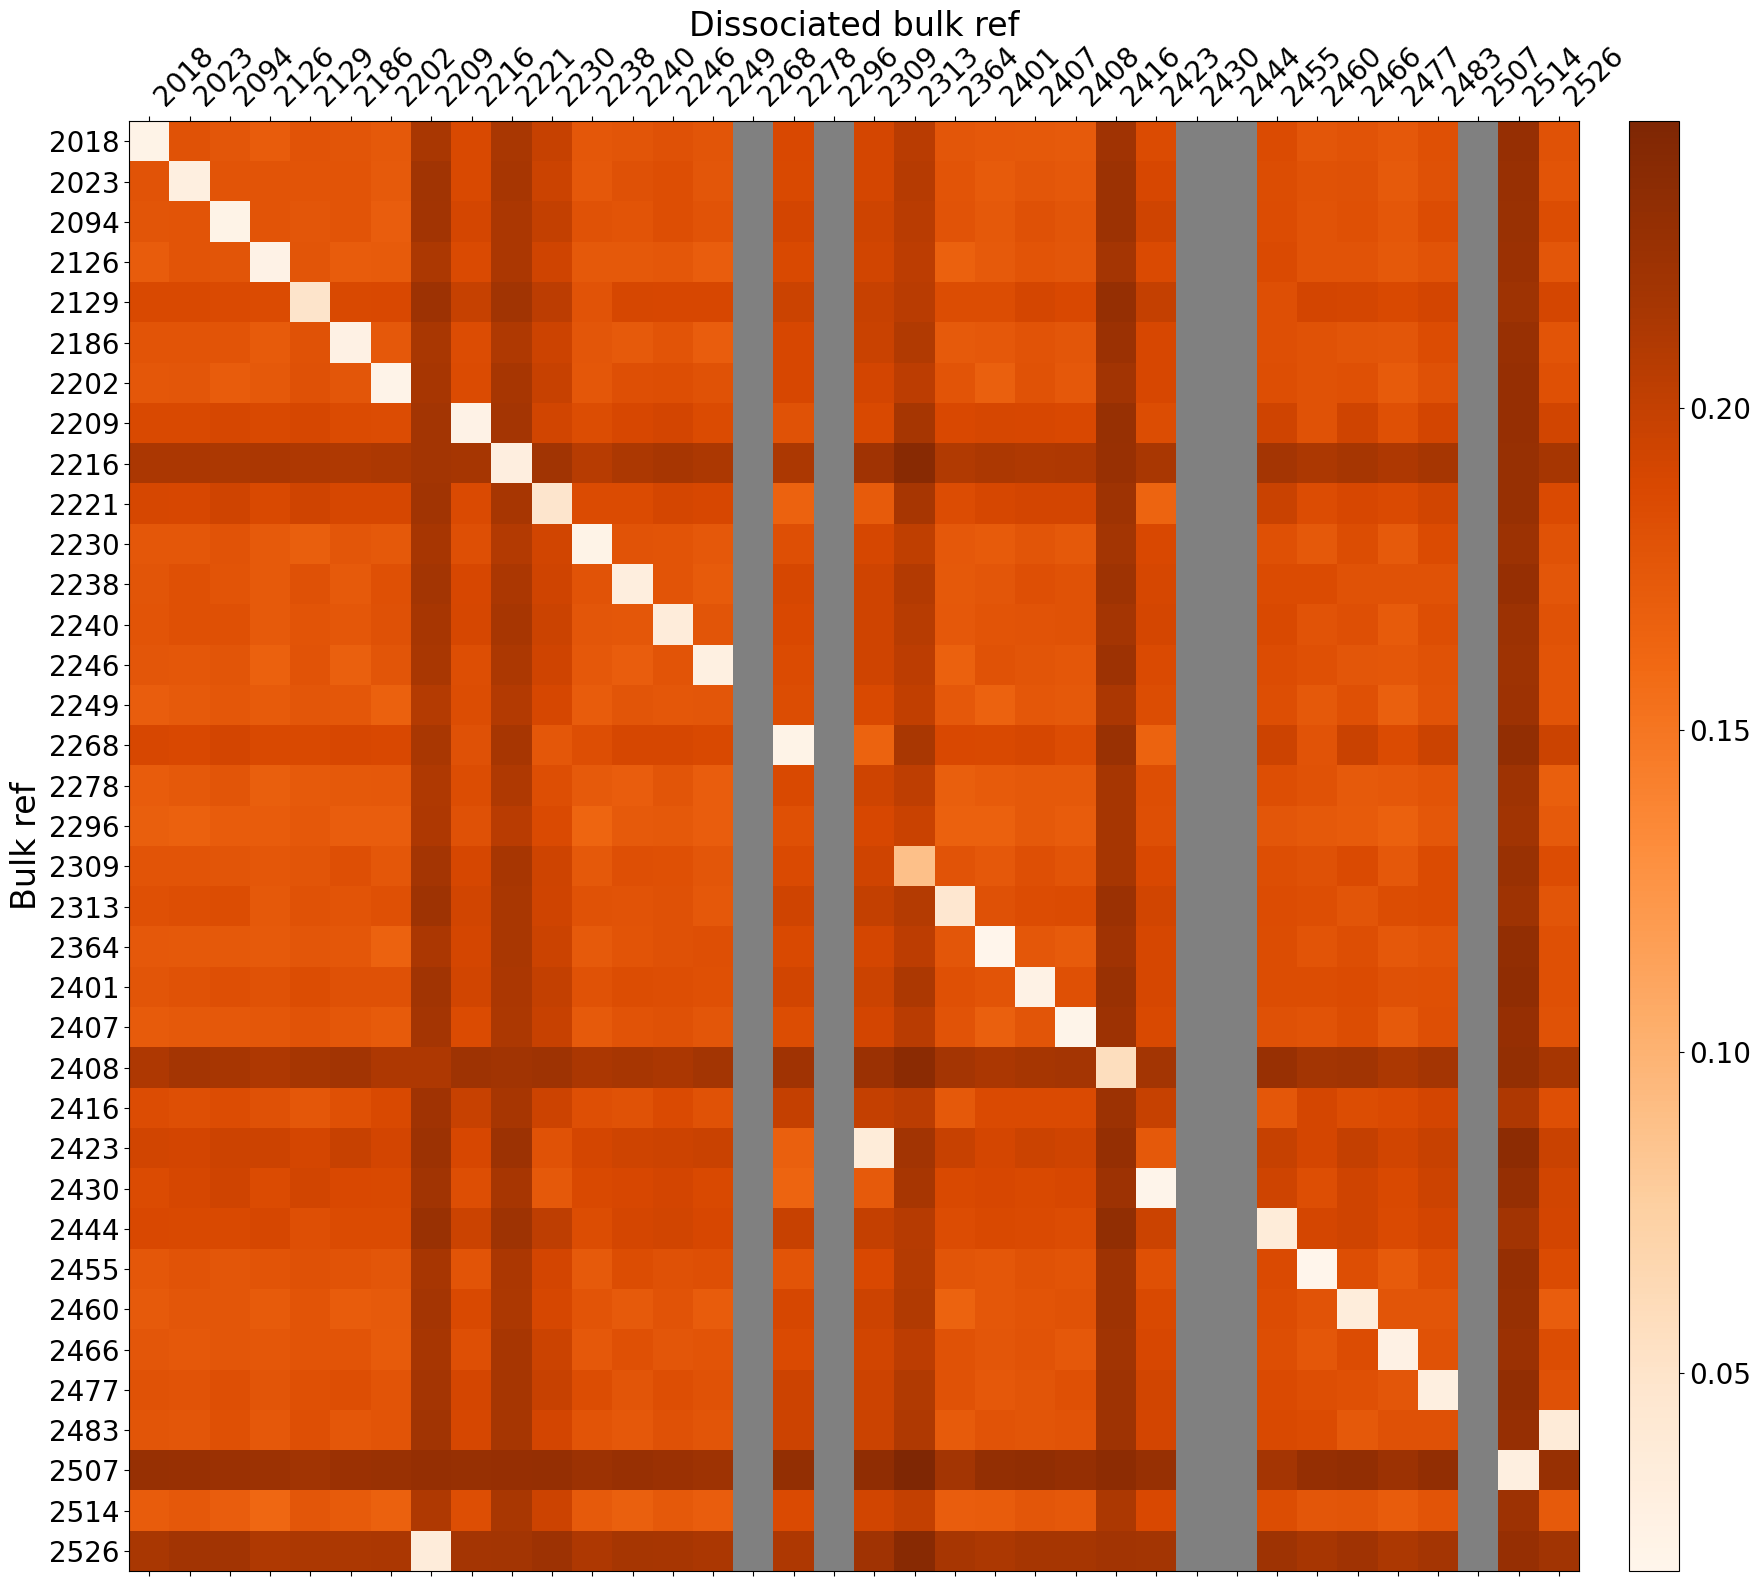

In [43]:
fig, ax = plt.subplots(figsize=(20, 20))
cmap = mpl.colormaps.get_cmap('Oranges')  # viridis is the default colormap for imshow
cmap.set_bad(color='grey')
heatmap = ax.matshow(sorted_df, cmap=cmap)

# # Numbers in grid
# for (i, j), z in np.ndenumerate(sorted_df):
#     ax.text(j, i, "{:.2f}".format(z), ha="center", va="center", fontdict={"fontsize": 6})

ax.set_xticks(np.arange(len(df.columns)))
ax.set_yticks(np.arange(len(df)))
ax.set_xticklabels(sorted_df.columns, rotation=45, ha="left", fontdict={"fontsize": 20})
ax.set_yticklabels(sorted_df.index, fontdict={"fontsize": 20})
ax.xaxis.set_label_position("top")
ax.set_xlabel("Dissociated bulk ref", fontsize=24)
ax.set_ylabel("Bulk ref", fontsize=24)
# ax.set_title("Distance between samples")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size=0.5, pad=0.5)
cbar = fig.colorbar(heatmap, cax=cax)
cbar.ax.tick_params(labelsize=20)

plt.show()

In [44]:
filename = f"../figures/bulk_diss_bulk_heatmap_qual_dp900_w2507_all_samples_poster"
fig.savefig(filename + ".pdf", bbox_inches="tight")
fig.savefig(filename + ".png", bbox_inches="tight")